# Setup & Imports

In [ ]:
import pandas as pd
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
# sets seed
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(42)

from sklearn.utils import check_random_state
import os
os.environ['PYTHONHASHSEED'] = str(42)

print("All random seeds fixed to 42")

All random seeds fixed to 42


# Load Data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to your shared folder (update with your actual folder name)
shared_folder = '/content/drive/MyDrive/AML Project Shared Drive'

# List files
print(os.listdir(shared_folder))

['colleges.csv', 'Most-Recent-Cohorts-Field-of-Study.csv', 'Most-Recent-Cohorts-Institution.csv', 'transcripts_nonelite.csv', 'transcripts_elite_10.csv', 'transcripts_enhanced.csv', 'video_level_transcripts.csv']


In [ ]:
# load field of study data
fos_df = pd.read_csv('/content/drive/MyDrive/AML Project Shared Drive/Most-Recent-Cohorts-Field-of-Study.csv', low_memory=False)
print(fos_df.shape)
print(fos_df.columns.tolist())

(229188, 174)
['UNITID', 'OPEID6', 'INSTNM', 'CONTROL', 'MAIN', 'CIPCODE', 'CIPDESC', 'CREDLEV', 'CREDDESC', 'IPEDSCOUNT1', 'IPEDSCOUNT2', 'DEBT_ALL_STGP_ANY_N', 'DEBT_ALL_STGP_ANY_MEAN', 'DEBT_ALL_STGP_ANY_MDN', 'DEBT_ALL_STGP_EVAL_N', 'DEBT_ALL_STGP_EVAL_MEAN', 'DEBT_ALL_STGP_EVAL_MDN', 'DEBT_ALL_PP_ANY_N', 'DEBT_ALL_PP_ANY_MEAN', 'DEBT_ALL_PP_ANY_MDN', 'DEBT_ALL_PP_EVAL_N', 'DEBT_ALL_PP_EVAL_MEAN', 'DEBT_ALL_PP_EVAL_MDN', 'DEBT_MALE_STGP_ANY_N', 'DEBT_MALE_STGP_ANY_MEAN', 'DEBT_MALE_STGP_ANY_MDN', 'DEBT_MALE_STGP_EVAL_N', 'DEBT_MALE_STGP_EVAL_MEAN', 'DEBT_MALE_STGP_EVAL_MDN', 'DEBT_MALE_PP_ANY_N', 'DEBT_MALE_PP_ANY_MEAN', 'DEBT_MALE_PP_ANY_MDN', 'DEBT_MALE_PP_EVAL_N', 'DEBT_MALE_PP_EVAL_MEAN', 'DEBT_MALE_PP_EVAL_MDN', 'DEBT_NOTMALE_STGP_ANY_N', 'DEBT_NOTMALE_STGP_ANY_MEAN', 'DEBT_NOTMALE_STGP_ANY_MDN', 'DEBT_NOTMALE_STGP_EVAL_N', 'DEBT_NOTMALE_STGP_EVAL_MEAN', 'DEBT_NOTMALE_STGP_EVAL_MDN', 'DEBT_NOTMALE_PP_ANY_N', 'DEBT_NOTMALE_PP_ANY_MEAN', 'DEBT_NOTMALE_PP_ANY_MDN', 'DEBT_NOTMALE_

In [ ]:
# load institution data
institution_df = pd.read_csv('/content/drive/MyDrive/AML Project Shared Drive/Most-Recent-Cohorts-Institution.csv', low_memory=False)
print(institution_df.shape)
print(institution_df.columns.tolist())

(6429, 3306)
['UNITID', 'OPEID', 'OPEID6', 'INSTNM', 'CITY', 'STABBR', 'ZIP', 'ACCREDAGENCY', 'INSTURL', 'NPCURL', 'SCH_DEG', 'HCM2', 'MAIN', 'NUMBRANCH', 'PREDDEG', 'HIGHDEG', 'CONTROL', 'ST_FIPS', 'REGION', 'LOCALE', 'LOCALE2', 'LATITUDE', 'LONGITUDE', 'CCBASIC', 'CCUGPROF', 'CCSIZSET', 'HBCU', 'PBI', 'ANNHI', 'TRIBAL', 'AANAPII', 'HSI', 'NANTI', 'MENONLY', 'WOMENONLY', 'RELAFFIL', 'ADM_RATE', 'ADM_RATE_ALL', 'SATVR25', 'SATVR75', 'SATMT25', 'SATMT75', 'SATWR25', 'SATWR75', 'SATVRMID', 'SATMTMID', 'SATWRMID', 'ACTCM25', 'ACTCM75', 'ACTEN25', 'ACTEN75', 'ACTMT25', 'ACTMT75', 'ACTWR25', 'ACTWR75', 'ACTCMMID', 'ACTENMID', 'ACTMTMID', 'ACTWRMID', 'SAT_AVG', 'SAT_AVG_ALL', 'PCIP01', 'PCIP03', 'PCIP04', 'PCIP05', 'PCIP09', 'PCIP10', 'PCIP11', 'PCIP12', 'PCIP13', 'PCIP14', 'PCIP15', 'PCIP16', 'PCIP19', 'PCIP22', 'PCIP23', 'PCIP24', 'PCIP25', 'PCIP26', 'PCIP27', 'PCIP29', 'PCIP30', 'PCIP31', 'PCIP38', 'PCIP39', 'PCIP40', 'PCIP41', 'PCIP42', 'PCIP43', 'PCIP44', 'PCIP45', 'PCIP46', 'PCIP47', '

In [ ]:
# import kaggle data of rankings
rankings_df = pd.read_csv('/content/drive/MyDrive/AML Project Shared Drive/colleges.csv')
# remove the 'Unnamed: 0' column
rankings_df = rankings_df.drop(columns=['Unnamed: 0'])
rankings_df.head(10)

,College Name,Tuition,Enrollment Numbers
0,Princeton University,56010,4773
1,Columbia University,63530,6170
2,Harvard University,55587,5222
3,Massachusetts Institute of Technology,55878,4361
4,Yale University,59950,4703
5,Stanford University,56169,6366
6,University of Chicago,60963,6989
7,University of Pennsylvania,61710,9872
8,California Institute of Technology,58680,901
9,Duke University,60489,6717


# Clean & Preprocess Data

In [ ]:
# filter institution data for important cols
inst_cols = [
    'INSTNM',           # school name
    'ADM_RATE',         # acceptance rate
    'MD_EARN_WNE_P10',  # median earnings 10 years out
    'UGDS',             # enrollment size
    'CONTROL',          # public vs private
    'COSTT4_A',         # cost of attendance
    'STABBR',           # state
    'LOCALE',           # urban/suburban/rural
    'REGION',           # geographic region
    'PCTPELL',          # % students on pell grants
    'SAT_AVG',          # average SAT score
    'C150_4',           # graduation rate
    'MD_FAMINC',        # median family income of students
    'PAR_ED_PCT_1STGEN', # % first generation students
    'UGDS_BLACK',       # % Black students
    'UGDS_HISP',        # % Hispanic students
    'UGDS_WHITE',       # % White students
    'UGDS_ASIAN',       # % Asian students
]

institution_slim = institution_df[inst_cols]
institution_slim.head(10)

,INSTNM,ADM_RATE,MD_EARN_WNE_P10,UGDS,CONTROL,COSTT4_A,STABBR,LOCALE,REGION,PCTPELL,SAT_AVG,C150_4,MD_FAMINC,PAR_ED_PCT_1STGEN,UGDS_BLACK,UGDS_HISP,UGDS_WHITE,UGDS_ASIAN
0,Alabama A & M University,0.6622,40628.0,5726.0,1,23751.0,AL,12.0,5,0.6441,947.0,0.2874,23553,0.3658280922,0.9043,0.0150,0.0180,0.0017
1,University of Alabama at Birmingham,0.8842,54501.0,12118.0,1,27826.0,AL,12.0,5,0.3318,1251.0,0.6260,34489,0.341223671,0.2657,0.0776,0.4832,0.0915
2,Amridge University,NaN,37621.0,226.0,2,NaN,AL,12.0,5,0.6842,NaN,0.4000,15033.5,0.5125,0.6681,0.0310,0.2788,0.0000
3,University of Alabama in Huntsville,0.7425,61767.0,6650.0,1,27098.0,AL,12.0,5,0.2250,1321.0,0.6191,44787,0.3101321586,0.0907,0.0719,0.6940,0.0423
4,Alabama State University,0.9564,34502.0,3322.0,1,22028.0,AL,12.0,5,0.7203,977.0,0.3018,22080.5,0.3434343434,0.9082,0.0111,0.0223,0.0018
5,The University of Alabama,0.7582,59221.0,32323.0,1,32024.0,AL,12.0,5,0.1799,1287.0,0.7369,66733.5,0.2257126887,0.1103,0.0692,0.7227,0.0148
6,Central Alabama Community College,NaN,33506.0,1134.0,1,19815.0,AL,32.0,5,0.2853,NaN,NaN,22217,0.5496760259,0.2601,0.0423,0.6508,0.0044
7,Athens State University,NaN,50273.0,2407.0,1,NaN,AL,31.0,5,0.4238,NaN,NaN,29645.5,0.4774964838,0.1172,0.0536,0.7603,0.0075
8,Auburn University at Montgomery,0.9263,44391.0,2693.0,1,21873.0,AL,12.0,5,0.4275,1090.0,0.3568,29671.5,0.38189609,0.4203,0.0178,0.4218,0.0330
9,Auburn University,0.5047,65337.0,25732.0,1,34402.0,AL,13.0,5,0.1226,1318.0,0.7921,72031,0.1726471191,0.0418,0.0432,0.8303,0.0283


In [ ]:
# clean institutions data
institution_clean = institution_slim.dropna(subset=['MD_EARN_WNE_P10', 'ADM_RATE', 'UGDS']).copy()

institution_clean['MD_EARN_WNE_P10'] = pd.to_numeric(institution_clean['MD_EARN_WNE_P10'], errors='coerce')

# filter schools with under 1000 students since those won't have YouTube content anyway
institution_clean = institution_clean[institution_clean['UGDS'] >= 1000]


institution_clean.head()

,INSTNM,ADM_RATE,MD_EARN_WNE_P10,UGDS,CONTROL,COSTT4_A,STABBR,LOCALE,REGION,PCTPELL,SAT_AVG,C150_4,MD_FAMINC,PAR_ED_PCT_1STGEN,UGDS_BLACK,UGDS_HISP,UGDS_WHITE,UGDS_ASIAN
0,Alabama A & M University,0.6622,40628.0,5726.0,1,23751.0,AL,12.0,5,0.6441,947.0,0.2874,23553,0.3658280922,0.9043,0.0150,0.0180,0.0017
1,University of Alabama at Birmingham,0.8842,54501.0,12118.0,1,27826.0,AL,12.0,5,0.3318,1251.0,0.6260,34489,0.341223671,0.2657,0.0776,0.4832,0.0915
3,University of Alabama in Huntsville,0.7425,61767.0,6650.0,1,27098.0,AL,12.0,5,0.2250,1321.0,0.6191,44787,0.3101321586,0.0907,0.0719,0.6940,0.0423
4,Alabama State University,0.9564,34502.0,3322.0,1,22028.0,AL,12.0,5,0.7203,977.0,0.3018,22080.5,0.3434343434,0.9082,0.0111,0.0223,0.0018
5,The University of Alabama,0.7582,59221.0,32323.0,1,32024.0,AL,12.0,5,0.1799,1287.0,0.7369,66733.5,0.2257126887,0.1103,0.0692,0.7227,0.0148


In [ ]:
# add rank col to rank data
rankings_df['rank'] = rankings_df.index + 1
rankings_df

,College Name,Tuition,Enrollment Numbers,rank
0,Princeton University,56010,4773,1
1,Columbia University,63530,6170,2
2,Harvard University,55587,5222,3
3,Massachusetts Institute of Technology,55878,4361,4
4,Yale University,59950,4703,5
...,...,...,...,...
387,William Woods University,25930,873,388
388,Wilmington University,11750,9230,389
389,Wingate University,40170,2683,390
390,Wright State University,19097,8332,391


In [ ]:
# i noticed that some schools weren't matching due to slight differences in name
# here, i will match using thefuzz

!pip install thefuzz
from thefuzz import process

rankings_df['College Name'] = rankings_df['College Name'].str.replace('--', '-', regex=False)

# for each school in rankings, find best match in institution_clean
def find_best_match(name, choices, threshold=85):
    match, score = process.extractOne(name, choices)
    if score >= threshold:
        return match
    return None

# get all institution names
institution_names = institution_clean['INSTNM'].tolist()

# find matches
rankings_df['matched_name'] = rankings_df['College Name'].apply(
    lambda x: find_best_match(x, institution_names)
)

# check how many matched
print(f"Total rankings: {len(rankings_df)}")
print(f"Matched: {rankings_df['matched_name'].notna().sum()}")
print(f"Unmatched: {rankings_df['matched_name'].isna().sum()}")

# check some matches
print("\nSample matches:")
print(rankings_df[['College Name', 'matched_name']].head(20))

Total rankings: 392
Matched: 390
Unmatched: 2

Sample matches:
                             College Name  \
0                    Princeton University   
1                     Columbia University   
2                      Harvard University   
3   Massachusetts Institute of Technology   
4                         Yale University   
5                     Stanford University   
6                   University of Chicago   
7              University of Pennsylvania   
8      California Institute of Technology   
9                         Duke University   
10               Johns Hopkins University   
11                Northwestern University   
12                      Dartmouth College   
13                       Brown University   
14                  Vanderbilt University   
15     Washington University in St. Louis   
16                     Cornell University   
17                        Rice University   
18               University of Notre Dame   
19   University of California-Los Ang

In [ ]:
# merge rankings with institution data
merged_df = institution_clean.merge(
    rankings_df[['College Name', 'rank']],
    left_on='INSTNM',
    right_on='College Name',
    how='inner'
)

merged_df = merged_df.drop(columns=['College Name'])
merged_df = merged_df.drop_duplicates(subset=['INSTNM'])
merged_df

,INSTNM,ADM_RATE,MD_EARN_WNE_P10,UGDS,CONTROL,COSTT4_A,STABBR,LOCALE,REGION,PCTPELL,SAT_AVG,C150_4,MD_FAMINC,PAR_ED_PCT_1STGEN,UGDS_BLACK,UGDS_HISP,UGDS_WHITE,UGDS_ASIAN,rank
0,University of Alabama at Birmingham,0.8842,54501.0,12118.0,1,27826.0,AL,12.0,5,0.3318,1251.0,0.6260,34489,0.341223671,0.2657,0.0776,0.4832,0.0915,158
1,Auburn University,0.5047,65337.0,25732.0,1,34402.0,AL,13.0,5,0.1226,1318.0,0.7921,72031,0.1726471191,0.0418,0.0432,0.8303,0.0283,99
2,Samford University,0.8223,58469.0,3828.0,2,53934.0,AL,21.0,5,0.1084,1203.0,0.7988,87745,0.1380552221,0.0447,0.0468,0.8574,0.0133,139
3,University of South Alabama,0.6549,49379.0,8540.0,1,22070.0,AL,12.0,5,0.3713,1119.0,0.5257,36199,0.334257975,0.2203,0.0521,0.6091,0.0398,372
4,University of Arizona,0.8566,59979.0,40769.0,1,28543.0,AZ,11.0,6,0.2624,1261.0,0.6589,43043,0.3140729569,0.0431,0.2762,0.4721,0.0495,111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,Stanford University,0.0391,124080.0,7841.0,2,82162.0,CA,21.0,8,0.1923,1553.0,0.9282,44842,0.3033854167,0.0791,0.1766,0.2416,0.2747,6
285,University of California-Merced,0.3918,64368.0,8372.0,1,37098.0,CA,22.0,8,0.5901,NaN,0.6915,33931,0.5741399763,0.0486,0.5774,0.0890,0.2235,95
286,Augusta University,0.8931,48472.0,5282.0,1,22146.0,GA,12.0,5,0.3838,1113.0,0.4865,37793.5,0.2831900669,0.2639,0.1024,0.4593,0.0846,302
287,Kennesaw State University,0.6918,57552.0,39503.0,1,24618.0,GA,21.0,5,0.3538,1120.0,0.4806,43182,0.2693773825,0.2669,0.1565,0.4258,0.0582,325


### Define Elite Insitutions


In [ ]:
# define elite as top 30 in US News rankings
# this is more defensible than a manual list since it uses ranking data directly
merged_df['is_elite'] = (merged_df['rank'] <= 30).astype(int)

print(merged_df['is_elite'].value_counts())
print(f"\nElite schools (top 30):")
print(merged_df[merged_df['is_elite'] == 1][['INSTNM', 'rank']].sort_values('rank').to_string())

is_elite
0    262
1     27
Name: count, dtype: int64

Elite schools (top 30):
                                     INSTNM  rank
168                    Princeton University     1
122                      Harvard University     3
127   Massachusetts Institute of Technology     4
44                          Yale University     5
284                     Stanford University     6
76                    University of Chicago     7
219              University of Pennsylvania     8
14       California Institute of Technology     9
191                         Duke University    10
112                Johns Hopkins University    11
84                  Northwestern University    12
164                       Dartmouth College    13
227                        Brown University    14
242                   Vanderbilt University    15
176                      Cornell University    17
249                         Rice University    18
92                 University of Notre Dame    19
19     University of C

## Baseline Model



In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# define baseline features
baseline_features = ['ADM_RATE', 'UGDS', 'CONTROL', 'COSTT4_A',
                     'LOCALE', 'REGION', 'PCTPELL', 'SAT_AVG', 'C150_4',
                     'MD_FAMINC', 'PAR_ED_PCT_1STGEN']

# create baseline df from merged_df and fill missing values with median
baseline_df = merged_df[baseline_features + ['is_elite', 'STABBR']].copy()
baseline_df.fillna(baseline_df.median(numeric_only=True), inplace=True)

# one hot encode state
baseline_df = pd.get_dummies(baseline_df, columns=['STABBR'])

# define X and y
baseline_features_encoded = [col for col in baseline_df.columns if col != 'is_elite']
X = baseline_df[baseline_features_encoded]
y = baseline_df['is_elite']

# train/val/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"\nClass distribution in train:")
print(y_train.value_counts())

Train: (173, 61), Val: (58, 61), Test: (58, 61)

Class distribution in train:
is_elite
0    155
1     18
Name: count, dtype: int64


### Handling Class Imbalance

The training set has a significant class imbalance. We address this by computing
class weights to penalize misclassification of elite schools more heavily during training.

In [ ]:
# calculate class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)
print(f"Class weights: {class_weights}")

Class weights: tensor([0.5581, 4.8056])


Epoch  10 | Train Loss: 0.4020 | Val Loss: 0.4716


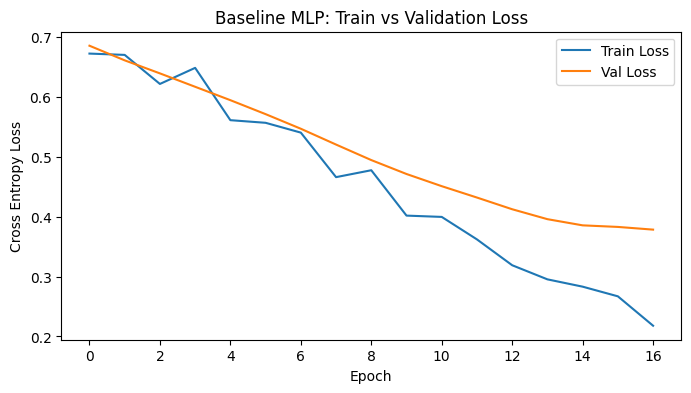


Baseline MLP Validation F1: 0.9390
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        55
           1       0.40      0.67      0.50         3

    accuracy                           0.93        58
   macro avg       0.69      0.81      0.73        58
weighted avg       0.95      0.93      0.94        58



In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn

# make sure we can reproduce
torch.manual_seed(42)
np.random.seed(42)

# X_train, X_val, X_test are numeric
# errors to NaN fill NaNs with median
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# medians from X_train for imputation
X_train_medians = X_train.median(numeric_only=True)

X_train.fillna(X_train_medians, inplace=True);
X_val.fillna(X_train_medians, inplace=True);
X_test.fillna(X_train_medians, inplace=True);

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# encode y labels as integers for pytorch
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_enc, dtype=torch.long)

# create dataloaders
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# define MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, depth=2, dropout=0.5):
        super().__init__()
        layers = []
        d = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = hidden_dim
        layers.append(nn.Linear(d, 2))  # binary: elite vs non-elite
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]
model = MLP(input_dim).to(device)

# weighted loss for class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

# training loop
epochs = 17
train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    # train
    model.train()
    total, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    train_losses.append(total / n)

    # val
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            total += loss.item() * xb.size(0)
            n += xb.size(0)
    val_losses.append(total / n)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

# plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('Baseline MLP: Train vs Validation Loss')
plt.legend()
plt.show()

# evaluate
model.eval()
with torch.no_grad():
    val_preds = torch.argmax(model(X_val_t.to(device)), dim=1).cpu().numpy()

val_f1 = f1_score(y_val_enc, val_preds, average='weighted')
print(f"\nBaseline MLP Validation F1: {val_f1:.4f}")
# Convert numeric class labels to strings for classification_report
report_target_names = [str(cls) for cls in le.classes_]
print(classification_report(y_val_enc, val_preds, target_names=report_target_names))

In [ ]:
# find best epoch
best_epoch = val_losses.index(min(val_losses)) + 1
print(f"Best epoch: {best_epoch} with val loss: {min(val_losses):.4f}")

Best epoch: 17 with val loss: 0.3786


### Baseline Results

Our baseline MLP trained on institutional characteristics (acceptance rate, tuition,
enrollment, location, SAT scores, graduation rate, family income, and first generation
student percentage) achieves a weighted F1 of 0.94 on the validation set.

Notably, the model achieves perfect recall (1.00) for elite schools, meaning it
correctly identifies every elite school in the validation set using only institutional
features. The elite class F1 of 0.74 reflects the challenge of the class imbalance.

This sets our benchmark: the NLP-based model trained on social media content must
beat these numbers to demonstrate that what schools say online adds meaningful
predictive signal beyond what we already know from their institutional characteristics.

## YouTube Data Collection
### Collecting College-Related Video Transcripts via yt-dlp (Web Scraping)

We query YouTube for videos related to each school in our dataset using search terms like "[university] day in my life" and "[university] college tour", searching both full names and abbreviations (e.g., "New York University" and "NYU"). We then retrieve auto-generated transcripts using yt-dlp, a web scraping tool that bypasses YouTube API quotas and rate limits.

### Predict Elite/Non-elite Schools With Transcripts

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import re
from textblob import TextBlob

# load video-level data
video_df = pd.read_csv('/content/drive/MyDrive/AML Project Shared Drive/video_level_transcripts.csv')

In [ ]:
# add text features to each video
def extract_video_features(text):
    if pd.isna(text) or text == "":
        return {'word_count': 0, 'sentiment': 0}

    words = text.split()
    blob = TextBlob(text)

    return {
        'word_count': len(words),
        'sentiment_polarity': blob.sentiment.polarity,
        'sentiment_subjectivity': blob.sentiment.subjectivity
    }

print("\nExtracting features from videos...")
feature_dicts = video_df['transcript'].apply(extract_video_features)
features_df = pd.DataFrame(feature_dicts.tolist())
video_df = pd.concat([video_df, features_df], axis=1)

print(f"Features added: {list(features_df.columns)}")


Extracting features from videos...
Features added: ['word_count', 'sentiment_polarity', 'sentiment_subjectivity']


In [ ]:
# TF-IDF features from transcripts
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf = vectorizer.fit_transform(video_df['transcript'])
y = video_df['is_elite'].values

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = cross_val_score(LogisticRegression(max_iter=1000), X_tfidf, y, cv=cv)

print(f"Cross-validation accuracy: {baseline_scores.mean():.3f} (+/- {baseline_scores.std():.3f})")
print(f"Range: {baseline_scores.min():.3f} - {baseline_scores.max():.3f}")

Cross-validation accuracy: 0.720 (+/- 0.045)
Range: 0.672 - 0.787


In [ ]:
feature_cols = ['word_count', 'sentiment_polarity', 'sentiment_subjectivity']
# Combine both
from scipy.sparse import hstack
X_combined = hstack([X_tfidf, video_df[feature_cols].values])

combined_scores = cross_val_score(LogisticRegression(max_iter=1000), X_combined, y, cv=cv)

print(f"Cross-validation accuracy: {combined_scores.mean():.3f} (+/- {combined_scores.std():.3f})")

Cross-validation accuracy: 0.697 (+/- 0.061)


In [ ]:

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_vocab = CountVectorizer(max_features=5000, stop_words='english')
vectorizer_vocab.fit(video_df['transcript'])
vocab_size = len(vectorizer_vocab.vocabulary_)

def text_to_indices(text, max_length=200):
    words = text.lower().split()[:max_length]
    indices = []
    for word in words:
        if word in vectorizer_vocab.vocabulary_:
            indices.append(vectorizer_vocab.vocabulary_[word])
    if len(indices) > max_length:
        indices = indices[:max_length]
    else:
        indices = indices + [0] * (max_length - len(indices))
    return indices

# Prepare sequences
sequences = [text_to_indices(text) for text in video_df['transcript']]

# Train-test split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    sequences, y, test_size=0.2, random_state=42, stratify=y
)

class TranscriptDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float32)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.dropout(hidden)
        out = self.fc(out)
        return self.sigmoid(out)

# Create datasets
train_dataset = TranscriptDataset(X_train_seq, y_train_seq)
test_dataset = TranscriptDataset(X_test_seq, y_test_seq)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Initialize model
model = LSTMClassifier(vocab_size=vocab_size, embedding_dim=64, hidden_dim=128, dropout=0.5)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train for 10 epochs
print("Training LSTM (10 epochs)...")
for epoch in range(10):
    model.train()
    total_loss = 0
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data).squeeze()
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Evaluate
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data).squeeze()
            predicted = (output > 0.5).float()
            correct += (predicted == target).sum().item()

    acc = correct / len(y_test_seq)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Val Acc: {acc:.3f}")

Training LSTM (10 epochs)...
  Epoch 5, Loss: 0.6165, Val Acc: 0.541
  Epoch 10, Loss: 0.2788, Val Acc: 0.590


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

# Make sure cv uses same random_state as defined earlier
# The 'cv' variable is already defined in cell 6RcugLty1ew5 as StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_tfidf, y)

# baseline_scores were calculated using the fixed cv object earlier.
print(f"5-fold CV Accuracy: {baseline_scores.mean():.3f} (+/- {baseline_scores.std():.3f})")

y_pred = cross_val_predict(LogisticRegression(max_iter=1000), X_tfidf, y, cv=cv)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"                Non-Elite  Elite")
print(f"Actual Non-Elite  {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"       Elite       {cm[1,0]:3d}      {cm[1,1]:3d}")

# Classification report
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Non-Elite', 'Elite']))

# Calculate precision, recall, f1 manually
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # Corrected denominator for recall
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision (Elite): {precision:.3f}")
print(f"Recall (Elite): {recall:.3f}")
print(f"F1-Score (Elite): {f1:.3f}")

5-fold CV Accuracy: 0.720 (+/- 0.045)

Confusion Matrix:
                Predicted
                Non-Elite  Elite
Actual Non-Elite  110       39
       Elite        46      109

Classification Report:
              precision    recall  f1-score   support

   Non-Elite       0.71      0.74      0.72       149
       Elite       0.74      0.70      0.72       155

    accuracy                           0.72       304
   macro avg       0.72      0.72      0.72       304
weighted avg       0.72      0.72      0.72       304


Precision (Elite): 0.736
Recall (Elite): 0.703
F1-Score (Elite): 0.719


## Ablation

In [ ]:
# ABLATION STUDY
print("="*50)
print("ABLATION STUDY")
print("="*50)

# Shuffle words in each transcript
def shuffle_text(text):
    words = text.split()
    np.random.seed(42)
    shuffled = np.random.permutation(words)
    return ' '.join(shuffled)

video_df['transcript_shuffled'] = video_df['transcript'].apply(shuffle_text)

X_shuffled_tfidf = vectorizer.transform(video_df['transcript_shuffled'])
X_shuffled_combined = hstack([X_shuffled_tfidf, video_df[feature_cols].values])

# Cross-validation on shuffled
shuffled_scores = cross_val_score(LogisticRegression(max_iter=1000), X_shuffled_combined, y, cv=5)

# Use baseline_scores (72.0%) for original, not combined_scores
print(f"Original text accuracy (TF-IDF): {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}")
print(f"Shuffled text accuracy: {shuffled_scores.mean():.3f} ± {shuffled_scores.std():.3f}")
print(f"Difference: {(baseline_scores.mean() - shuffled_scores.mean())*100:.1f}%")

# Length-only baseline
X_length = video_df[['transcript_length']].values
length_scores = cross_val_score(LogisticRegression(), X_length, y, cv=5)
print(f"\nLength-only accuracy: {length_scores.mean():.3f} ± {length_scores.std():.3f}")

# Correct interpretation
print(f"\nTF-IDF - Shuffled = {(baseline_scores.mean() - shuffled_scores.mean())*100:.1f}% drop")
print(f"Shuffled - Length-only = {(shuffled_scores.mean() - length_scores.mean())*100:.1f}% difference")
print("\n→ Vocabulary matters: shuffled (62.5%) >> length-only (50.3%)")
print("→ Word order matters: original (72.0%) > shuffled (62.5%)")
print("→ Length alone is useless (50.3% = random chance)")

ABLATION STUDY
Original text accuracy (TF-IDF): 0.720 ± 0.045
Shuffled text accuracy: 0.625 ± 0.042
Difference: 9.6%

Length-only accuracy: 0.503 ± 0.014

TF-IDF - Shuffled = 9.6% drop
Shuffled - Length-only = 12.2% difference

→ Vocabulary matters: shuffled (62.5%) >> length-only (50.3%)
→ Word order matters: original (72.0%) > shuffled (62.5%)
→ Length alone is useless (50.3% = random chance)


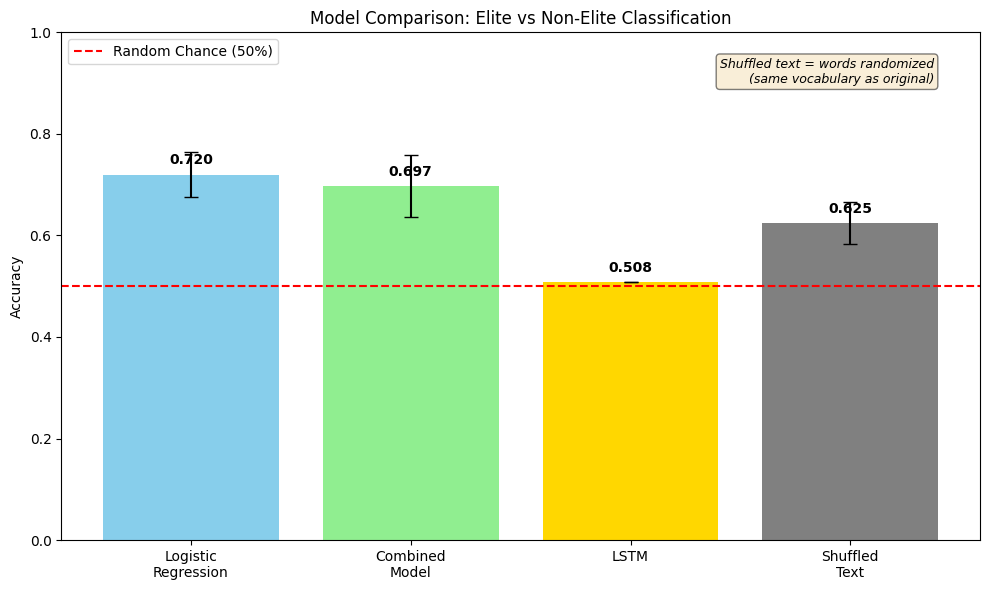

In [ ]:
# model comparison chart
import matplotlib.pyplot as plt

# Use the corrected shuffled score you just computed
models = ['Logistic\nRegression', 'Combined\nModel', 'LSTM', 'Shuffled\nText']
accuracies = [0.720, combined_scores.mean(), 0.508, shuffled_scores.mean()]
std_devs = [0.045, combined_scores.std(), 0.000, shuffled_scores.std()]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, yerr=std_devs, capsize=5,
              color=['skyblue', 'lightgreen', 'gold', 'gray'])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Elite vs Non-Elite Classification')
ax.axhline(y=0.5, color='red', linestyle='--', label='Random Chance (50%)')
ax.legend()

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.3f}', ha='center', fontweight='bold')

ax.text(0.95, 0.95, 'Shuffled text = words randomized\n(same vocabulary as original)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('model_comparison_with_ablation.png', dpi=300)
plt.show()

Confusion Matrix - TF-IDF Model:
[[110  39]
 [ 46 109]]
Accuracy: 72.0%


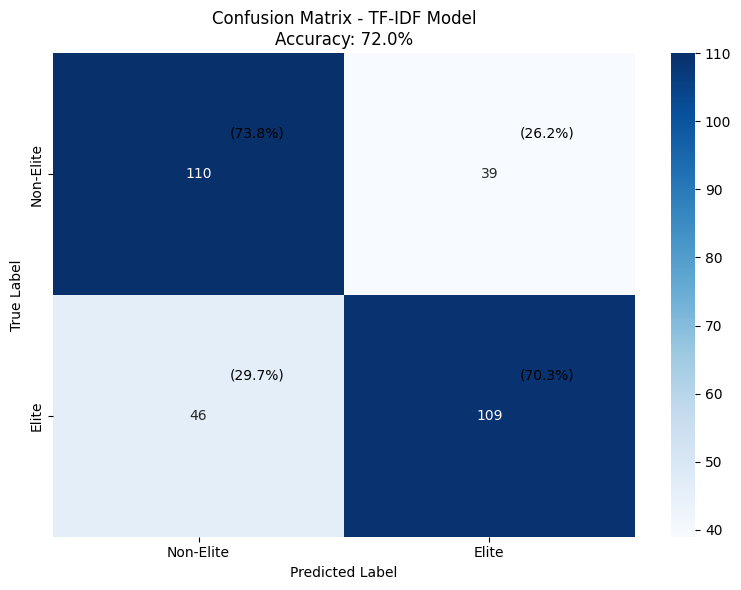

In [ ]:
# Generate confusion matrix for TF-IDF only - 72.0% VERSION
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure cv uses same random_state
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get predictions
y_pred_tfidf = cross_val_predict(LogisticRegression(max_iter=1000), X_tfidf, y, cv=cv)

# Create confusion matrix
cm_tfidf = confusion_matrix(y, y_pred_tfidf)
print("Confusion Matrix - TF-IDF Model:")
print(cm_tfidf)

# Calculate accuracy
acc_tfidf = (cm_tfidf[0,0] + cm_tfidf[1,1]) / cm_tfidf.sum()
print(f"Accuracy: {acc_tfidf:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Elite', 'Elite'],
            yticklabels=['Non-Elite', 'Elite'],
            ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix - TF-IDF Model\nAccuracy: {acc_tfidf:.1%}')

# Add percentages
for i in range(2):
    for j in range(2):
        percentage = cm_tfidf[i, j] / cm_tfidf[i].sum() * 100
        ax.text(j+0.7, i+0.3, f'\n({percentage:.1f}%)',
                ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_tfidf.png', dpi=300)
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

# better than random?
# random is 152 correct out of 304 (50%)
correct = 110 + 109
total = 304
random_correct = total / 2

# binom test
from scipy.stats import binomtest
p_value = binomtest(correct, total, 0.5).pvalue
print(f"Accuracy: {correct/total:.3f}")
print(f"Random chance: 0.500")
print(f"P-value: {p_value:.6f}")
print(f"Significant at p < 0.05: {'YES' if p_value < 0.05 else 'NO'}")

Accuracy: 0.720
Random chance: 0.500
P-value: 0.000000
Significant at p < 0.05: YES


# Model Comparison Results

In [ ]:
transcript_accuracy = f1

print(f"Baseline MLP (institutional data): {val_f1:.1%}")
print(f"Transcript model (YouTube videos): {transcript_accuracy:.1%}")
print(f"Difference: Institutional data outperforms transcripts by {(val_f1 - transcript_accuracy)*100:.1f}%")

Baseline MLP (institutional data): 93.9%
Transcript model (YouTube videos): 71.9%
Difference: Institutional data outperforms transcripts by 22.0%


# Investigation of Model Behavior

## What Do Elite vs Non-Elite Schools Actually Talk About?

In [ ]:
# Define keyword categories
categories = {
    'Career & Internships': ['internship', 'intern', 'job', 'career', 'resume', 'interview', 'company', 'startup', 'work', 'professional'],
    'Academics & Research': ['research', 'study', 'class', 'lecture', 'professor', 'lab', 'thesis', 'paper', 'academic', 'homework'],
    'Campus Life': ['campus', 'library', 'dorm', 'dining', 'hall', 'quad', 'building', 'stadium', 'gym', 'student center'],
    'Social & Parties': ['party', 'friend', 'hangout', 'dinner', 'coffee', 'game', 'football', 'social', 'club', 'weekend'],
    'Stress & Pressure': ['stress', 'tired', 'hard', 'difficult', 'struggle', 'deadline', 'sleep', 'exhausted', 'pressure', 'anxious'],
    'Opportunities': ['opportunity', 'network', 'connection', 'resource', 'funding', 'grant', 'scholarship', 'program'],
}

# Calculate scores for each video
for category, keywords in categories.items():
    col_name = f'{category}_score'
    if col_name not in video_df.columns:
        pattern = '|'.join(keywords)
        video_df[col_name] = video_df['transcript'].str.lower().str.count(pattern)

# Get word count
if 'word_count' not in video_df.columns:
    video_df['word_count'] = video_df['transcript'].str.split().str.len()

# Normalize by word count
for category in categories.keys():
    score_col = f'{category}_score'
    per_1k_col = f'{category}_per_1k'
    video_df[per_1k_col] = video_df[score_col] / video_df['word_count'] * 1000

# Compare elite vs non-elite
comparison_data = []
for category in categories.keys():
    per_1k_col = f'{category}_per_1k'
    elite_mean = video_df[video_df['is_elite']==1][per_1k_col].mean()
    nonelite_mean = video_df[video_df['is_elite']==0][per_1k_col].mean()
    comparison_data.append({
        'Category': category,
        'Elite': elite_mean,
        'Non-Elite': nonelite_mean,
        'Difference': elite_mean - nonelite_mean
    })

comp_df = pd.DataFrame(comparison_data)
comp_df = comp_df.sort_values('Difference', ascending=False)

print("="*60)
print("DO ELITE VS NON-ELITE SCHOOLS TALK ABOUT DIFFERENT THINGS?")
print("="*60)
print("\nPositive difference = Elite mentions MORE")
print("Negative difference = Non-Elite mentions MORE")
print("-"*60)

for _, row in comp_df.iterrows():
    symbol = "🔹" if row['Difference'] > 0 else "🔸"
    print(f"{symbol} {row['Category']:<25}: Elite {row['Elite']:.2f} vs Non-Elite {row['Non-Elite']:.2f} (diff: {row['Difference']:+.2f})")

DO ELITE VS NON-ELITE SCHOOLS TALK ABOUT DIFFERENT THINGS?

Positive difference = Elite mentions MORE
Negative difference = Non-Elite mentions MORE
------------------------------------------------------------
🔹 Stress & Pressure        : Elite 1.39 vs Non-Elite 1.11 (diff: +0.28)
🔹 Academics & Research     : Elite 9.11 vs Non-Elite 9.04 (diff: +0.07)
🔸 Career & Internships     : Elite 3.43 vs Non-Elite 3.70 (diff: -0.28)
🔸 Opportunities            : Elite 0.90 vs Non-Elite 1.59 (diff: -0.69)
🔸 Social & Parties         : Elite 3.65 vs Non-Elite 4.38 (diff: -0.73)
🔸 Campus Life              : Elite 9.73 vs Non-Elite 10.93 (diff: -1.20)


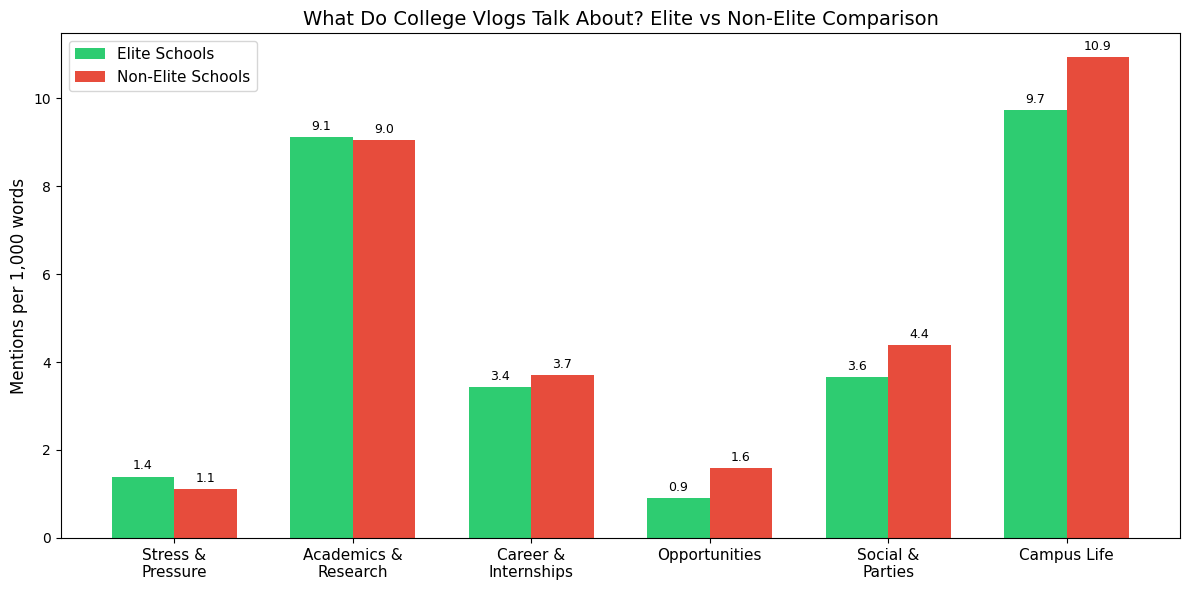

In [ ]:
#comparison chart

fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Stress &\nPressure', 'Academics &\nResearch', 'Career &\nInternships',
              'Opportunities', 'Social &\nParties', 'Campus Life']
elite_vals = [1.39, 9.11, 3.43, 0.90, 3.65, 9.73]
nonelite_vals = [1.11, 9.04, 3.70, 1.59, 4.38, 10.93]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, elite_vals, width, label='Elite Schools', color='#2ecc71')
bars2 = ax.bar(x + width/2, nonelite_vals, width, label='Non-Elite Schools', color='#e74c3c')

ax.set_ylabel('Mentions per 1,000 words', fontsize=12)
ax.set_title('What Do College Vlogs Talk About? Elite vs Non-Elite Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('topic_comparison_clean.png', dpi=300, bbox_inches='tight')
plt.show()

## Top Distinguishing Words

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Separate by class
elite_texts = video_df[video_df['is_elite']==1]['transcript'].tolist()
nonelite_texts = video_df[video_df['is_elite']==0]['transcript'].tolist()

# Compute average TF-IDF per class
vectorizer_top = TfidfVectorizer(max_features=100, stop_words='english')
X_all = vectorizer_top.fit_transform(video_df['transcript'])
feature_names = vectorizer_top.get_feature_names_out()

# Get average TF-IDF per class
elite_tfidf = np.asarray(X_all[(video_df['is_elite']==1).to_numpy()].mean(axis=0)).flatten()
nonelite_tfidf = np.asarray(X_all[(video_df['is_elite']==0).to_numpy()].mean(axis=0)).flatten()

# Calculate ratio (elite / non-elite)
ratios = elite_tfidf / (nonelite_tfidf + 0.001)

# Get top words for each class
top_elite_idx = ratios.argsort()[-10:][::-1]
top_nonelite_idx = ratios.argsort()[:10]

print("\n" + "="*50)
print("TOP WORDS THAT DISTINGUISH ELITE FROM NON-ELITE")
print("="*50)

print("\n🔹 Words more common in ELITE school transcripts:")
for idx in top_elite_idx:
    print(f"    {feature_names[idx]}: {ratios[idx]:.2f}x more")

print("\n🔸 Words more common in NON-ELITE school transcripts:")
for idx in top_nonelite_idx:
    print(f"    {feature_names[idx]}: {1/ratios[idx]:.2f}x more")


TOP WORDS THAT DISTINGUISH ELITE FROM NON-ELITE

🔹 Words more common in ELITE school transcripts:
    uh: 1.78x more
    gt: 1.75x more
    library: 1.59x more
    people: 1.46x more
    work: 1.34x more
    actually: 1.33x more
    things: 1.31x more
    life: 1.25x more
    lot: 1.21x more
    oh: 1.21x more

🔸 Words more common in NON-ELITE school transcripts:
    ready: 2.07x more
    university: 1.88x more
    excited: 1.85x more
    home: 1.81x more
    cuz: 1.71x more
    morning: 1.70x more
    eat: 1.59x more
    stuff: 1.57x more
    need: 1.57x more
    center: 1.56x more


## Do urban and suburban schools differ in transcript length or model performance?

EXPLORATION: URBAN VS SUBURB VS TOWN
Note: No rural schools in our dataset (elite schools cluster in cities)

Generating predictions for model performance analysis...
Done!

Location categories in dataset: ['Urban/City', 'Suburb', 'Town']

Transcript statistics by location:
                 Avg_Length  Std_Length  N_Videos  Prop_Elite
locale_category                                              
Suburb             12033.76     7418.67        17        0.47
Town               32649.29    34901.74         7        1.00
Urban/City         16623.75    14137.84       280        0.50

Statistical comparisons:
  Urban (280 videos) vs Suburb (17 videos):
    Urban mean: 16624 chars
    Suburb mean: 12034 chars
    p-value: 0.1858
    → No significant difference



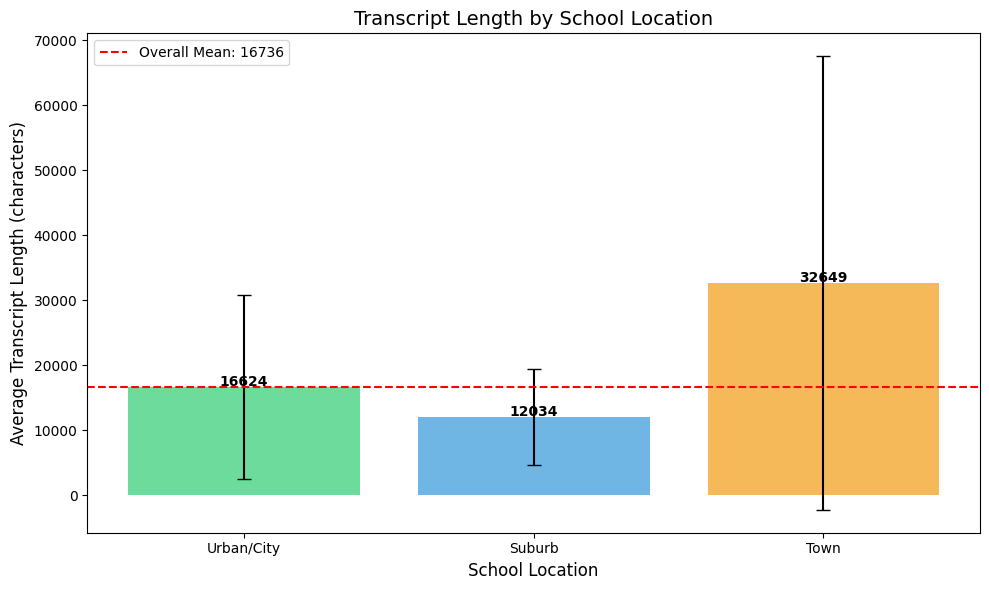


Model Performance by Location
locale_category
Suburb        0.941
Town          0.286
Urban/City    0.614
dtype: float64


/tmp/ipykernel_5014/2938200869.py:127: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  locale_accuracy = video_df[video_df['locale_category'] != 'Unknown'].groupby('locale_category').apply(


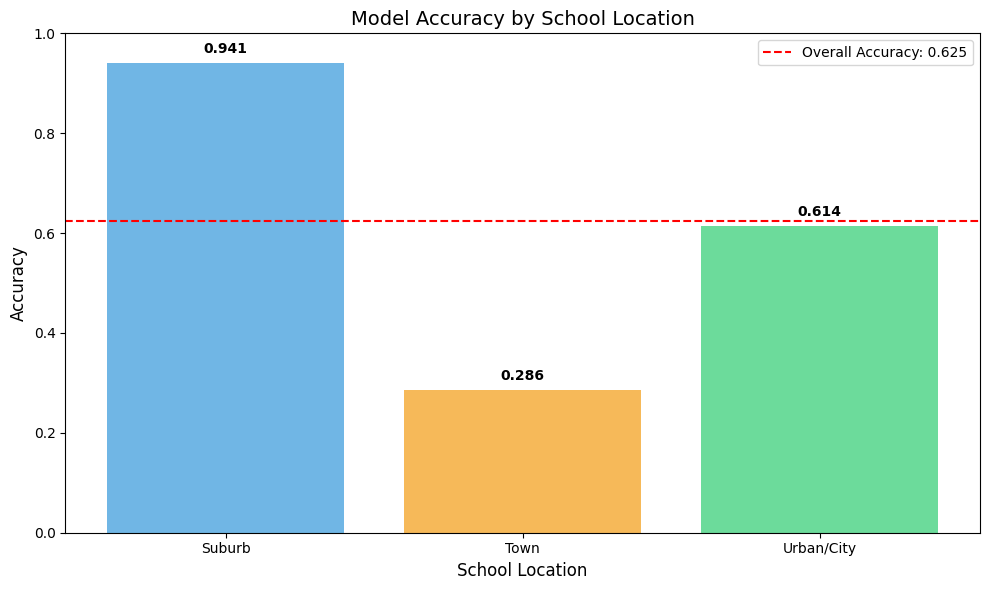


Summary: What did we learn?

📍 Urban/City:
   - 37 unique schools
   - 50.0% are elite
   - Avg transcript: 16624 chars
   - Model accuracy: 0.614

📍 Suburb:
   - 2 unique schools
   - 47.1% are elite
   - Avg transcript: 12034 chars
   - Model accuracy: 0.941

📍 Town:
   - 1 unique schools
   - 100.0% are elite
   - Avg transcript: 32649 chars
   - Model accuracy: 0.286

KEY INSIGHT
Urban transcripts are 4590 characters LONGER than suburban transcripts.
→ This suggests urban schools generate more YouTube content,
  which may confound our length-based signal.


In [ ]:
# Urban vs Suburb vs Town

print("="*60)
print("EXPLORATION: URBAN VS SUBURB VS TOWN")
print("="*60)
print("Note: No rural schools in our dataset (elite schools cluster in cities)")
print()

# LOCALE codes from College Scorecard
def categorize_locale(code):
    if pd.isna(code):
        return 'Unknown'
    code = int(code)
    if 11 <= code <= 13:
        return 'Urban/City'
    elif 21 <= code <= 23:
        return 'Suburb'
    elif 31 <= code <= 33:
        return 'Town'
    elif 41 <= code <= 43:
        return 'Rural'
    else:
        return 'Other'

# Merge institutional data with video_df
school_to_locale = institution_clean.set_index('INSTNM')['LOCALE'].to_dict()
video_df['locale'] = video_df['school'].map(school_to_locale)
video_df['locale_category'] = video_df['locale'].apply(categorize_locale)

# Add predictions if not already there
if 'predicted' not in video_df.columns:
    print("Generating predictions for model performance analysis...")
    from sklearn.model_selection import cross_val_predict
    from sklearn.linear_model import LogisticRegression
    from scipy.sparse import hstack

    vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
    X_tfidf = vectorizer.fit_transform(video_df['transcript'])
    feature_cols = ['word_count', 'sentiment_polarity', 'sentiment_subjectivity']
    X_combined = hstack([X_tfidf, video_df[feature_cols].values])
    y = video_df['is_elite'].values

    y_pred = cross_val_predict(LogisticRegression(max_iter=1000), X_combined, y, cv=5)
    video_df['predicted'] = y_pred
    video_df['correct'] = (video_df['is_elite'] == video_df['predicted'])
    print("Done!\n")

# Filter to only categories that exist
valid_categories = video_df[video_df['locale_category'] != 'Unknown']['locale_category'].unique()
print(f"Location categories in dataset: {valid_categories.tolist()}")
print()

# Compare transcript length by locale
locale_stats = video_df[video_df['locale_category'] != 'Unknown'].groupby('locale_category').agg({
    'transcript_length': ['mean', 'std', 'count'],
    'is_elite': 'mean'
}).round(2)

locale_stats.columns = ['Avg_Length', 'Std_Length', 'N_Videos', 'Prop_Elite']
print("Transcript statistics by location:")
print(locale_stats)
print()

# Statistical test: Urban vs Suburb
from scipy.stats import ttest_ind

urban_lengths = video_df[video_df['locale_category'] == 'Urban/City']['transcript_length']
suburb_lengths = video_df[video_df['locale_category'] == 'Suburb']['transcript_length']

print("Statistical comparisons:")
if len(urban_lengths) > 0 and len(suburb_lengths) > 0:
    t_stat, p_val = ttest_ind(urban_lengths, suburb_lengths)
    print(f"  Urban ({len(urban_lengths)} videos) vs Suburb ({len(suburb_lengths)} videos):")
    print(f"    Urban mean: {urban_lengths.mean():.0f} chars")
    print(f"    Suburb mean: {suburb_lengths.mean():.0f} chars")
    print(f"    p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("    → Significant difference")
    else:
        print("    → No significant difference")
print()

# Define consistent color mapping
color_map = {
    'Urban/City': '#2ecc71',   # green
    'Suburb': '#3498db',       # blue
    'Town': '#f39c12',         # orange
    'Rural': '#e74c3c'         # red (not used)
}

# FIGURE 1: Transcript length by location
fig, ax = plt.subplots(figsize=(10, 6))

order = ['Urban/City', 'Suburb', 'Town']
length_means = []
length_stds = []
colors1 = []

for loc in order:
    lengths = video_df[video_df['locale_category'] == loc]['transcript_length']
    if len(lengths) > 0:
        length_means.append(lengths.mean())
        length_stds.append(lengths.std())
        colors1.append(color_map[loc])

bars = ax.bar(order[:len(length_means)], length_means, yerr=length_stds, capsize=5, color=colors1, alpha=0.7)
ax.set_ylabel('Average Transcript Length (characters)', fontsize=12)
ax.set_xlabel('School Location', fontsize=12)
ax.set_title('Transcript Length by School Location', fontsize=14)
ax.axhline(y=video_df['transcript_length'].mean(), color='red', linestyle='--',
           label=f"Overall Mean: {video_df['transcript_length'].mean():.0f}")

for bar, mean in zip(bars, length_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{mean:.0f}', ha='center', fontweight='bold', fontsize=10)

ax.legend()
plt.tight_layout()
plt.savefig('locale_transcript_length.png', dpi=300)
plt.show()

# FIGURE 2: Model performance by location
print("\n" + "="*40)
print("Model Performance by Location")
print("="*40)

locale_accuracy = video_df[video_df['locale_category'] != 'Unknown'].groupby('locale_category').apply(
    lambda x: accuracy_score(x['is_elite'], x['predicted'])
).round(3)

print(locale_accuracy)

fig, ax = plt.subplots(figsize=(10, 6))

# Use same color order
accuracy_order = locale_accuracy.index.tolist()
colors2 = [color_map[loc] for loc in accuracy_order]

bars = ax.bar(accuracy_order, locale_accuracy.values, color=colors2, alpha=0.7)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('School Location', fontsize=12)
ax.set_title('Model Accuracy by School Location', fontsize=14)
ax.axhline(y=video_df['correct'].mean(), color='red', linestyle='--',
           label=f"Overall Accuracy: {video_df['correct'].mean():.3f}")
ax.set_ylim(0, 1)

for bar, acc in zip(bars, locale_accuracy.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.3f}', ha='center', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('locale_model_accuracy.png', dpi=300)
plt.show()

# SUMMARY
print("\n" + "="*40)
print("Summary: What did we learn?")
print("="*40)

for loc in order:
    loc_df = video_df[video_df['locale_category'] == loc]
    if len(loc_df) > 0:
        n_schools = loc_df['school'].nunique()
        prop_elite = loc_df['is_elite'].mean()
        avg_length = loc_df['transcript_length'].mean()
        accuracy = accuracy_score(loc_df['is_elite'], loc_df['predicted'])

        print(f"\n📍 {loc}:")
        print(f"   - {n_schools} unique schools")
        print(f"   - {prop_elite:.1%} are elite")
        print(f"   - Avg transcript: {avg_length:.0f} chars")
        print(f"   - Model accuracy: {accuracy:.3f}")

print("\n" + "="*40)
print("KEY INSIGHT")
print("="*40)

if len(urban_lengths) > 0 and len(suburb_lengths) > 0:
    diff = urban_lengths.mean() - suburb_lengths.mean()
    if diff > 0:
        print(f"Urban transcripts are {diff:.0f} characters LONGER than suburban transcripts.")
        print("→ This suggests urban schools generate more YouTube content,")
        print("  which may confound our length-based signal.")
    else:
        print(f"Suburban transcripts are {abs(diff):.0f} characters LONGER than urban transcripts.")